# Campaign 2

The purpose of this notebook is to analyze data taken during Campaign 2 of commissioning, which involved testing the DIB sensitivity to the SAA. 
We are mainly interested in verifying that the register READs are as expected (i.e. that there were no SEU or bit-flips present in the data). This requires us to confirm that imaging, the heater control system, and the hvps remained turned off throughout the day. Since MeDDEA was left on for several hours, we also want to investigate the housekeeping data to ensure that the temperatures, voltages, and currents were within their nominal ranges. 

These data were taken on 09-25-2025.

This notebook was last updated on 09-29-2025. 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.time import Time
from datetime import datetime
import astropy.units as u

from astropy.table import conf
from astropy.table import vstack
from astropy.timeseries import TimeSeries

import padre_meddea.io.file_tools as file_tools
from padre_meddea.io.file_tools import read_raw_file
from padre_meddea.housekeeping import calibration
from padre_meddea.util import validation
from padre_meddea.util.util import is_consecutive

from padre_meddea.io.file_tools import read_file

import padre_meddea.calibration.calibration as calibration
from padre_meddea.housekeeping import calibration

In [3]:
# Define function to plot housekeeping data.
def plot_hk_converted(hk_ts, key, axlabel, title, plot=False, hist=False):  
    data=hk_ts[key]
    f=calibration.get_calibration_func(key)
    converted_data=f(data)
    print(np.shape(converted_data))

    if plot==True: 
        plt.plot(hk_ts.time.to_datetime(), converted_data, label=key)
        plt.xticks(rotation=45, ha='right') 
        plt.title(title)
        plt.xlabel('UTC Time (HH:MM:SS)')
        plt.ylabel(axlabel)
        plt.grid()
        plt.legend()
        plt.show()

    if hist==True: 
        n, bins, patches=plt.hist(converted_data, bins=30, edgecolor='black', alpha=1, label=key)
        #plt.text(f'Mean: {np.mean(converted_data):.3} \n Standard Dev: {np.std(converted_data):.3}')
        plt.title(key)
        #plt.xlabel(axlabel)
        plt.ylabel('Counts')
        plt.grid()
        plt.legend()
        plt.show()

In [7]:
data_dir = Path(r"C:\Users\ngodbole\OneDrive - NASA\Desktop\analysis/data/commissioning_data")

In [8]:
# Read in the data.
l0_hk_files =['padre_meddea_l0_housekeeping_20250925T134442_v1.0.0.fits',
              'padre_meddea_l0_housekeeping_20250925T134442_v1.0.1.fits']

In [9]:
for this_file in l0_hk_files: 
    hk_ts, cmd_ts = read_file(data_dir / this_file)
    print(hk_ts, cmd_ts)
    print(f'Filename: {this_file} \n ')
    print(hk_ts['time'][0], hk_ts['time'][-1])

          time           pkttimes fp_temp ... error_summary checksum seqcount
----------------------- --------- ------- ... ------------- -------- --------
2025-09-25 13:44:42.000 812123087   31680 ...             0    42504        1
2025-09-25 13:44:52.000 812123097   31652 ...             0    42037        2
2025-09-25 13:45:02.000 812123107   31629 ...             0    42942        3
2025-09-25 13:45:12.000 812123117   31599 ...             0    42193        4
2025-09-25 13:45:22.000 812123127   31568 ...             0    41174        5
2025-09-25 13:45:32.000 812123137   31536 ...             0    42965        6
2025-09-25 13:45:42.000 812123147   31504 ...             0    42609        7
2025-09-25 13:45:52.000 812123157   31472 ...             0    42201        8
2025-09-25 13:46:02.000 812123167   31440 ...             0    42838        9
2025-09-25 13:46:12.000 812123177   31410 ...             0    42845       10
                    ...       ...     ... ...           ...     

In [10]:
l0_hk_ts, l0_cmd_ts = read_file(data_dir / l0_hk_files[0])

In [11]:
np.where(np.diff(l0_hk_ts['seqcount']) != 1.)

(array([], dtype=int64),)

This L0 data does not have repeated values of sequence count.

In [12]:
print(is_consecutive(l0_hk_ts['seqcount']))

True


In [13]:
l0_hk_ts['time']

<Time object: scale='utc' format='iso' value=['2025-09-25 13:44:42.000' '2025-09-25 13:44:52.000'
 '2025-09-25 13:45:02.000' ... '2025-09-26 11:33:32.000'
 '2025-09-26 11:33:42.000' '2025-09-26 11:33:52.000']>

In [14]:
l0_cmd_ts[l0_cmd_ts['name'] == 'mode']

time,pkttimes,pktclock,address,value,seqcount,name
Time,uint32,uint32,uint16,uint16,uint16,bytes17
2025-09-25 13:49:14.770,812123359,15397434,0,0,0,mode
2025-09-25 13:50:30.494,812123435,9876869,0,0,24,mode
2025-09-25 14:17:04.045,812125029,907271,0,0,27,mode
2025-09-25 15:15:19.812,812128524,16241591,0,0,50,mode
2025-09-25 15:52:34.161,812130759,3210655,0,0,53,mode
2025-09-25 16:54:18.709,812134463,14182874,0,0,76,mode
2025-09-25 17:41:34.281,812137299,5629911,0,0,79,mode
2025-09-25 18:31:16.732,812140281,14646619,0,0,102,mode
2025-09-25 20:02:54.865,812145779,17305593,0,0,105,mode


In [15]:
l0_cmd_ts[l0_cmd_ts['name'] == 'hvps_mode']

time,pkttimes,pktclock,address,value,seqcount,name
Time,uint32,uint32,uint16,uint16,uint16,bytes17
2025-09-25 13:49:18.273,812123363,5457698,3072,0,1,hvps_mode
2025-09-25 13:50:33.097,812123438,1936741,3072,0,25,hvps_mode
2025-09-25 14:18:04.108,812125089,2169278,3072,0,28,hvps_mode
2025-09-25 15:15:22.215,812128527,4299343,3072,0,51,hvps_mode
2025-09-25 15:53:34.207,812130819,4133825,3072,0,54,hvps_mode
2025-09-25 16:54:21.312,812134466,6240465,3072,0,77,hvps_mode
2025-09-25 17:42:34.326,812137359,6525402,3072,0,80,hvps_mode
2025-09-25 18:31:20.285,812140285,5706423,3072,0,103,hvps_mode
2025-09-25 20:02:57.318,812145782,6365466,3072,0,106,hvps_mode


In [16]:
l0_cmd_ts[l0_cmd_ts['name'] == 'heater_mode']

time,pkttimes,pktclock,address,value,seqcount,name
Time,uint32,uint32,uint16,uint16,uint16,bytes17
2025-09-25 13:49:21.476,812123366,9517216,2314,0,2,heater_mode
2025-09-25 13:50:35.350,812123440,7005384,2314,0,26,heater_mode
2025-09-25 14:19:04.182,812125149,3645036,2314,0,29,heater_mode
2025-09-25 15:15:25.468,812128530,9359434,2314,0,52,heater_mode
2025-09-25 15:54:34.239,812130879,4772870,2314,0,55,heater_mode
2025-09-25 16:54:23.766,812134468,15320717,2314,0,78,heater_mode
2025-09-25 17:43:34.375,812137419,7505401,2314,0,81,heater_mode
2025-09-25 18:31:22.738,812140287,14766564,2314,0,104,heater_mode
2025-09-25 20:02:59.672,812145784,13433757,2314,0,107,heater_mode


The mode, heater_mode, and hvps_mode were all 0 throughout this interval, which is as expected! 

Examine the error_summary. 

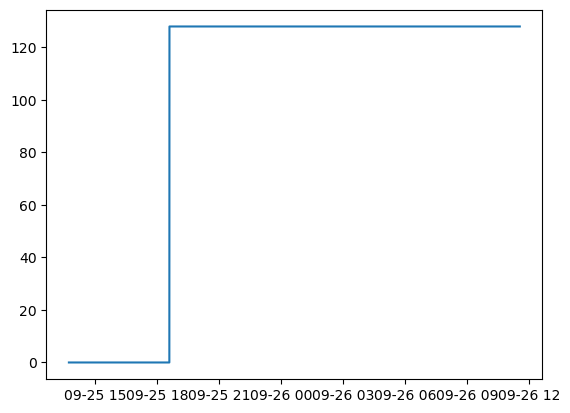

In [17]:
plt.plot(l0_hk_ts['time'].to_datetime(), l0_hk_ts['error_summary'])

In [18]:
l0_hk_ts[np.where(l0_hk_ts['error_summary'] == 128)][0]

time,pkttimes,fp_temp,dib_temp,hvps_temp,hvps_vsense,hvps_csense,csense_15v,csense_33vd,csense_33va,hit_rate,good_cmd_cnt,error_cnt,heater_pwm_duty_cycle,decimation_rate,error_summary,checksum,seqcount
Time,uint32,uint16,uint16,uint16,uint16,uint16,uint16,uint16,uint16,uint16,uint16,uint16,uint16,uint16,uint16,uint16,uint16
2025-09-25 18:36:32.000,812140597,31571,50960,40209,1079,4176,28131,36651,37012,0,112,0,0,0,128,63902,1752


The rogue_pps flag was tripped at 2025-09-25 18:36:32.000, about 3 minutes after the last live pass during which queued commands were sent. The rogue_pps is a known error flag that occurs periodically; we may wish to add a command to clear this flag periodically during flight. 

Verify that the ASIC threshold register READs are as expected.

In [21]:
existing_names = set(l0_cmd_ts['name'])

for this_asic in range(4):
    print(f"\nASIC {this_asic} Thresholds")
    for this_threshold in range(1, 17): 
        column_name = f'asic{this_asic}_threshold{this_threshold}'
        if column_name in existing_names:
            result = l0_cmd_ts[l0_cmd_ts['name']==column_name]
            print(f"{column_name}:")
            print(result)
            print()


ASIC 0 Thresholds
asic0_threshold1:
          time           pkttimes pktclock ... value seqcount       name      
----------------------- --------- -------- ... ----- -------- ----------------
2025-09-25 13:49:25.379 812123370  7577151 ... 15677        3 asic0_threshold1
2025-09-25 14:20:04.246 812125209  4921220 ... 15677       30 asic0_threshold1
2025-09-25 15:55:34.104 812130939  2072713 ... 15677       56 asic0_threshold1
2025-09-25 17:44:34.441 812137479  8826053 ... 15677       82 asic0_threshold1
2025-09-26 11:12:54.314 812200379  6283381 ... 15677      120 asic0_threshold1

asic0_threshold5:
          time           pkttimes pktclock ... value seqcount       name      
----------------------- --------- -------- ... ----- -------- ----------------
2025-09-25 13:49:37.191 812123382  3817096 ... 16189        7 asic0_threshold5
2025-09-25 14:24:04.111 812125449  2215840 ... 16189       34 asic0_threshold5
2025-09-25 15:59:34.142 812131179  2832547 ... 16189       60 asic0_thresho

Since the ASIC configurations have not been updated yet, we expect all of the ASIC threshold registers to have the same values as in the default configuration. 

The ASIC threshold register READs are as expected. 

Examine the sequence count.

Is the seqcount consecutive? True


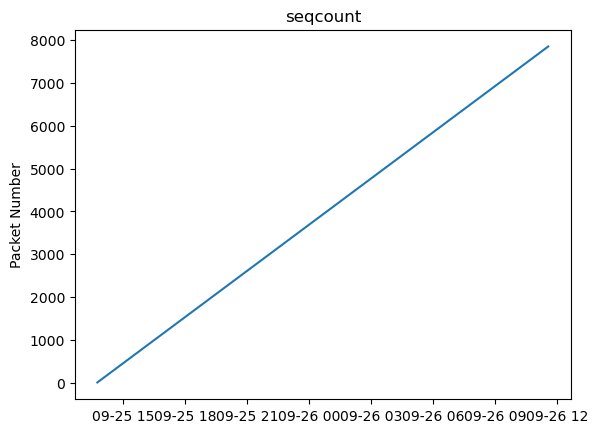

In [22]:
print('Is the seqcount consecutive?', is_consecutive(l0_hk_ts['seqcount']))

plt.plot(l0_hk_ts.time.to_datetime(), l0_hk_ts['seqcount'])
plt.title('seqcount')
plt.ylabel('Packet Number') 
plt.show()

Check that the temperatures, voltages, and currents are within limits. 

In [60]:
hk_converted = calibration.calibrate_hk_ts(l0_hk_ts)

(7856,)


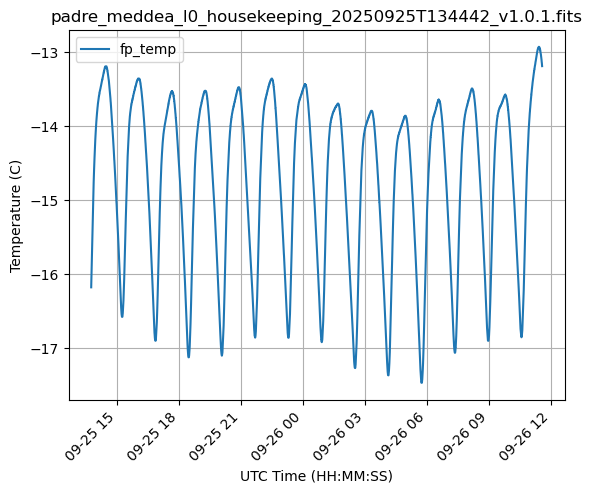

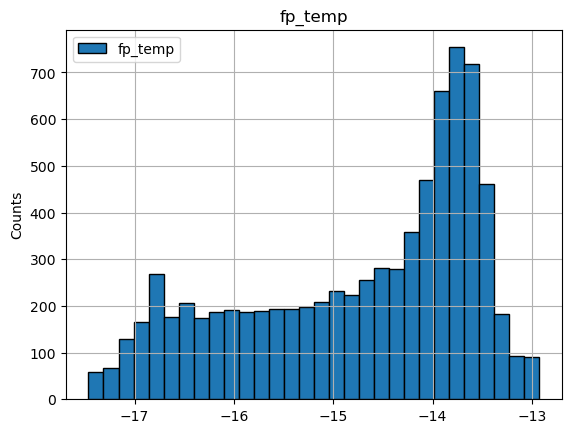

Summary:
fp_temp ranged from -17.465548251680094 deg_C to -12.924952951762478 deg_C .
Mean: -14.74121449939577 deg_C 
 Standard deviation 1.1689076224099808 deg_C .
(7856,)


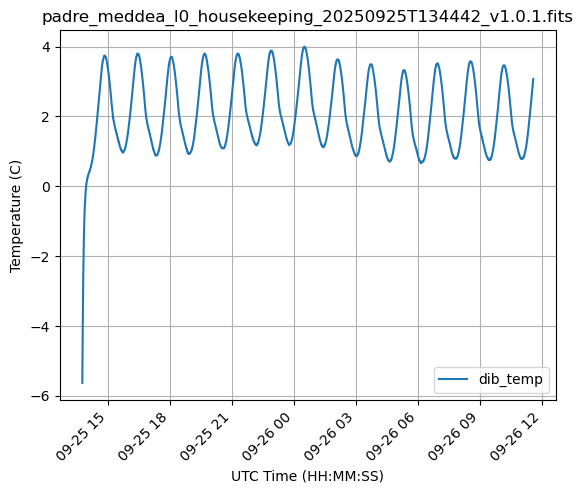

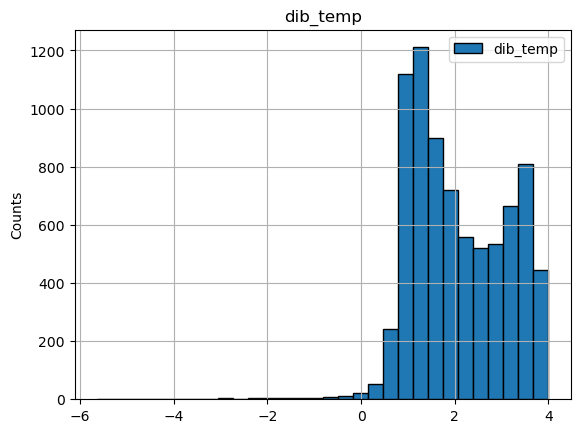

Summary:
dib_temp ranged from -5.631455055181126 deg_C to 3.994811081372373 deg_C .
Mean: 2.0628483635680164 deg_C 
 Standard deviation 1.046419664106948 deg_C .
(7856,)


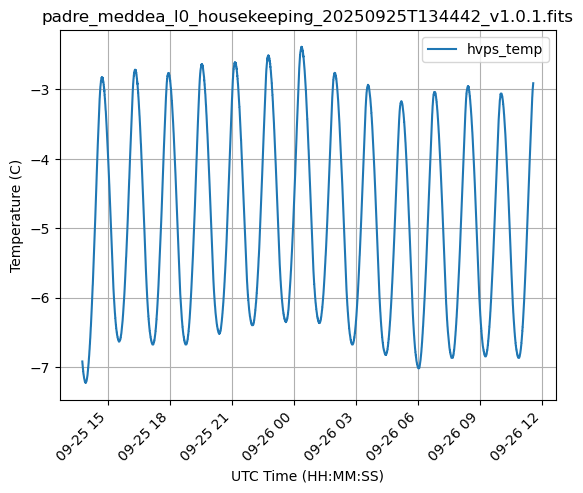

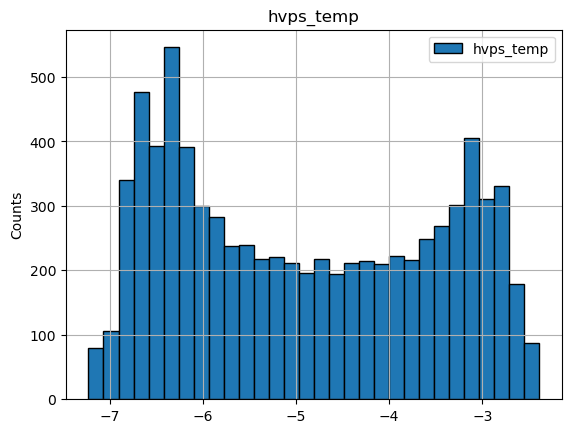

Summary:
hvps_temp ranged from -7.226441321081799 deg_C to -2.3876371911548966 deg_C .
Mean: -4.914104093896879 deg_C 
 Standard deviation 1.3961149810316218 deg_C .


In [61]:
# Plot the converted temperature data. 
temps = ['fp_temp', 'dib_temp', 'hvps_temp']

for this_temp in temps: 
    plot_hk_converted(l0_hk_ts, this_temp, 'Temperature (C)', str(l0_hk_files[0]), plot=True, hist=True) #fp_temp consistently stays within +/- 1C.

    print('Summary:')
    print(this_temp, 'ranged from', str(np.amin(hk_converted[this_temp])), 'to', str(np.amax(hk_converted[this_temp])), '.')
    print('Mean:', str(np.mean(hk_converted[this_temp])), '\n Standard deviation', str(np.std(hk_converted[this_temp])), '.')

(7856,)


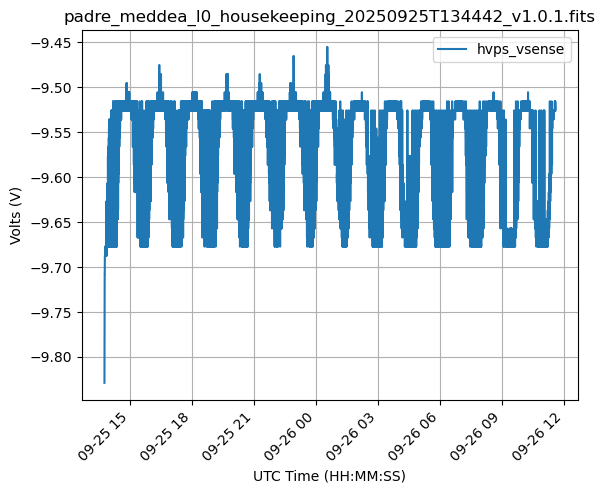

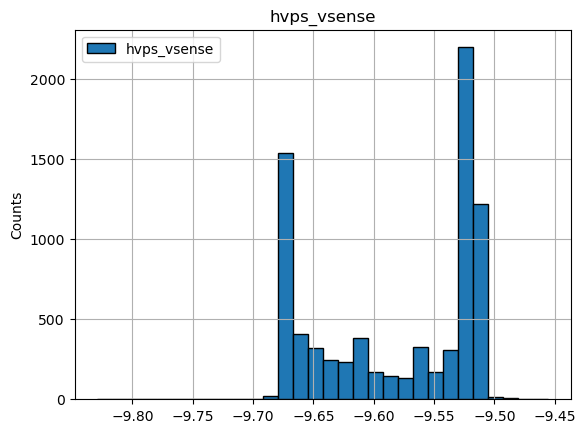

Summary:
hvps_vsense ranged from -9.829099999999999 V to -9.4554 V .
Mean: -9.582070404786151 V 
 Standard deviation 0.06404370801485769 V .
(7856,)


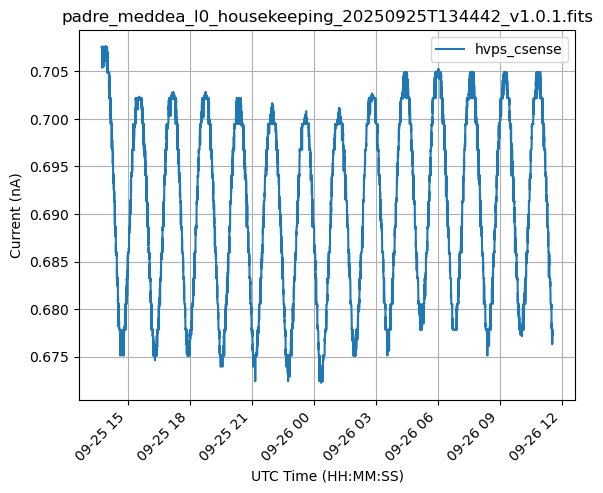

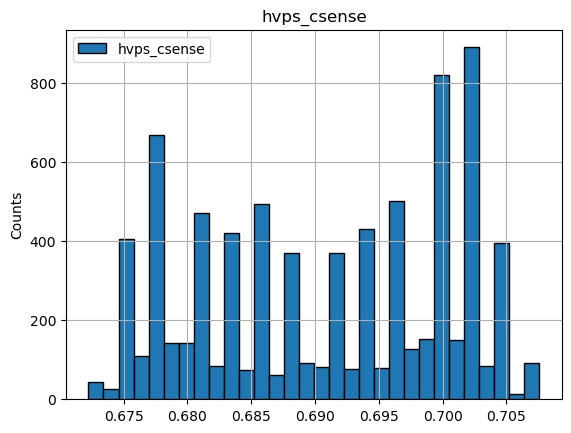

Summary:
hvps_csense ranged from 0.67223526 nA to 0.70758552 nA .
Mean: 0.6908650104760692 nA 
 Standard deviation 0.009746304190088751 nA .
(7856,)


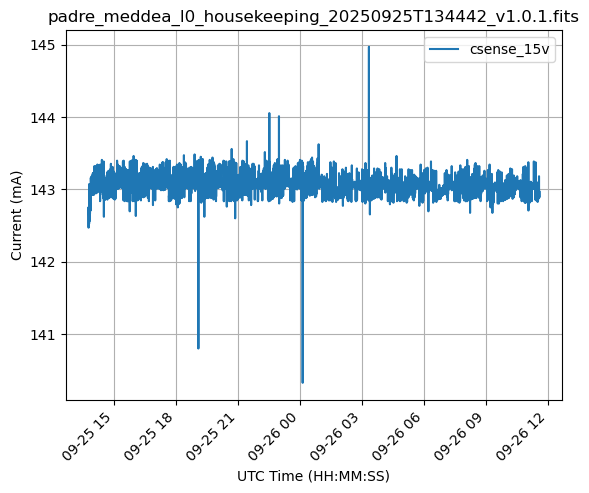

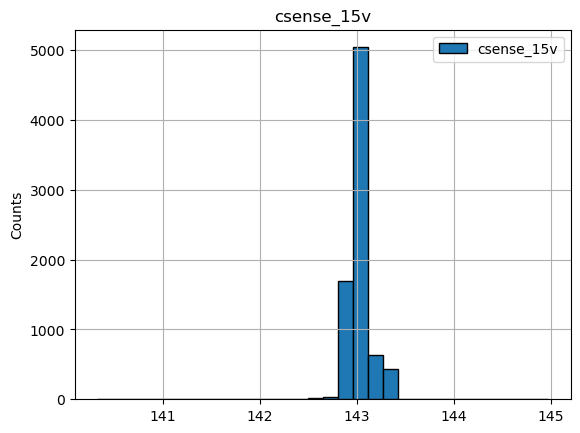

Summary:
csense_15v ranged from 140.32556799999998 mA to 144.97002399999997 mA .
Mean: 143.03654404073316 mA 
 Standard deviation 0.12060266587751872 mA .
(7856,)


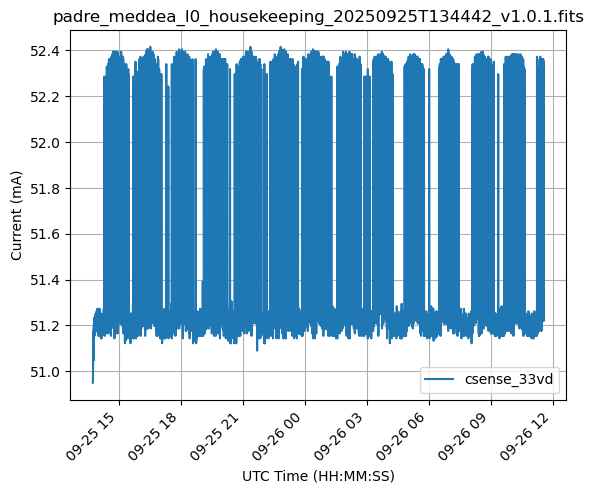

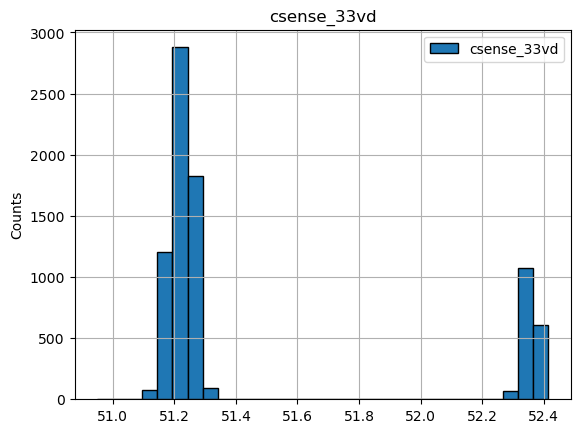

Summary:
csense_33vd ranged from 50.949423999999965 mA to 52.41496000000001 mA .
Mean: 51.47604887576374 mA 
 Standard deviation 0.4725039194657514 mA .
(7856,)


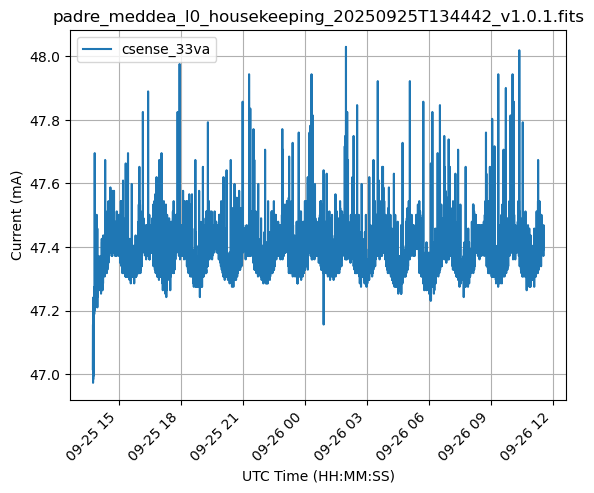

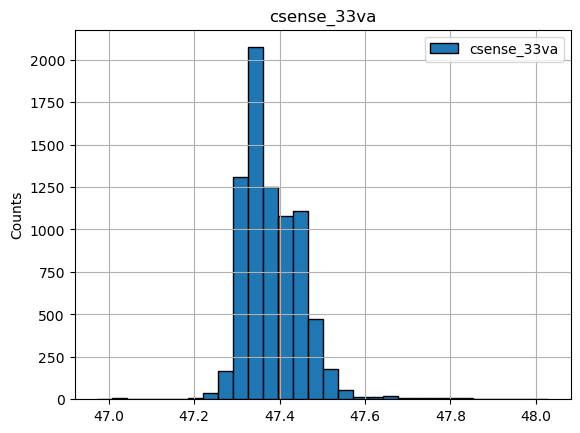

Summary:
csense_33va ranged from 46.97307999999998 mA to 48.02912799999996 mA .
Mean: 47.38188215478613 mA 
 Standard deviation 0.07401028522259413 mA .


In [ ]:
# Plot the converted voltage and current data. 

voltages = ['hvps_vsense']
currents = ['hvps_csense', 'csense_15v', 'csense_33vd', 'csense_33va']

for this_voltage in voltages: 
    plot_hk_converted(l0_hk_ts, this_voltage, 'Volts (V)', str(l0_hk_files[0]), plot=True, hist=True) #fp_temp consistently stays within +/- 1C.
 
    print('Summary:')
    print(this_voltage, 'ranged from', str(np.amin(hk_converted[this_voltage])), 'to', str(np.amax(hk_converted[this_voltage])), '.')
    print('Mean:', str(np.mean(hk_converted[this_voltage])), '\n Standard deviation', str(np.std(hk_converted[this_voltage])), '.')

for this_current in currents: 
    if this_current == 'hvps_csense': 
        plot_hk_converted(l0_hk_ts, this_current, 'Current (nA)', str(l0_hk_files[0]), plot=True, hist=True)
    else: 
        plot_hk_converted(l0_hk_ts, this_current, 'Current (mA)', str(l0_hk_files[0]), plot=True, hist=True)

    print('Summary:')
    print(this_current, 'ranged from', str(np.amin(hk_converted[this_current])), 'to', str(np.amax(hk_converted[this_current])), '.')
    print('Mean:', str(np.mean(hk_converted[this_current])), '\n Standard deviation', str(np.std(hk_converted[this_current])), '.')